# Green View Index from Google Street View

This notebook measures street-level greenery for a study area.

1. Lay a regular grid over the place boundary.
2. Ask the Street View Metadata API which points have an outdoor Google panorama.
3. Download four horizontal views (north, east, south, west) for each unique panorama.
4. Score each photo with a green-pixel mask, then average the four views into one Green View Index (GVI).
5. Map the point scores.

GVI here is the share of image pixels classified as vegetation, expressed as a percentage. The default classifier is an HSV green range, the same color threshold used in the campus pilot. Set `GVI_METHOD = "segformer"` to use Cityscapes vegetation and terrain classes instead.

Street View image requests are billed. Metadata requests are not. `MAX_POINTS` defaults to 5 so a first run stays small. Set it to `None` for the full grid.

Put a Google Maps API key in the environment before the download cells:

```bash
export GOOGLE_MAPS_API_KEY="your-key"
```

## Predicting GVI from satellite bands

Sections 7–14 use the street-level scores as labels. Sentinel-2 reflectance at those points trains a model, which then estimates GVI on a 10 m grid covering the campus. Put the joined training table at `data/ml_training.csv` and the phone-photo check at `data/ground_truth_gvi.csv`.

Set `MAPBOX_ACCESS_TOKEN` to draw the maps on Mapbox Streets. With no token, the maps use CartoDB, which needs no key. The maps published for review are the CartoDB versions. Sampling Sentinel-2 for the full grid needs the Earth Engine client, a completed `earthengine authenticate`, and `EARTHENGINE_PROJECT`.


In [1]:
import os
from pathlib import Path

import cv2
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from shapely.geometry import Point
from tqdm.auto import tqdm

# --- study area ---
PLACE_NAME = "Chiang Mai University, Chiang Mai, Thailand"
GRID_SPACING_M = 50
SEARCH_RADIUS_M = 50
UTM_EPSG = 32647  # northern Thailand

# --- Street View ---
HEADINGS = [0, 90, 180, 270]
PITCH = 0
FOV = 90
IMAGE_SIZE = "640x640"
REQUIRE_GOOGLE_COPYRIGHT = True
MAX_POINTS = 5  # None downloads every unique panorama

# --- greenery ---
# OpenCV HSV ranges. Hue 35-90 covers typical foliage and excludes yellow-green signs.
LOWER_GREEN = np.array([35, 43, 46])
UPPER_GREEN = np.array([90, 255, 255])
GVI_METHOD = "hsv"  # "hsv" or "segformer"

DATA_DIR = Path("data")
IMAGE_DIR = Path("images")
DATA_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)

API_KEY = os.environ.get("GOOGLE_MAPS_API_KEY", "").strip()
METADATA_URL = "https://maps.googleapis.com/maps/api/streetview/metadata"
IMAGE_URL = "https://maps.googleapis.com/maps/api/streetview"
MAPBOX_TOKEN = os.environ.get("MAPBOX_ACCESS_TOKEN", "").strip()
if MAPBOX_TOKEN:
    MAPBOX_TILES = (
        "https://api.mapbox.com/styles/v1/mapbox/streets-v12/tiles/256/{z}/{x}/{y}@2x"
        f"?access_token={MAPBOX_TOKEN}"
    )
    MAPBOX_ATTR = "Mapbox | © OpenStreetMap contributors"
else:
    MAPBOX_TILES = "CartoDB positron"
    MAPBOX_ATTR = "© OpenStreetMap contributors © CARTO"

print(f"Place: {PLACE_NAME}")
print(f"GVI method: {GVI_METHOD}")
print(f"API key loaded: {bool(API_KEY)}")


Place: Chiang Mai University, Chiang Mai, Thailand
GVI method: hsv
API key loaded: False


## 1. Sample points inside the study area

The boundary comes from OpenStreetMap through OSMnx. Points are spaced on a metric grid, then clipped to the campus polygon so the sample stays inside the place.


In [2]:
def build_grid(place_name, spacing_m, utm_epsg):
    boundary = ox.geocode_to_gdf(place_name)
    projected = boundary.to_crs(epsg=utm_epsg)
    polygon = projected.geometry.iloc[0]
    minx, miny, maxx, maxy = polygon.bounds

    points = [
        Point(x, y)
        for x in np.arange(minx, maxx, spacing_m)
        for y in np.arange(miny, maxy, spacing_m)
        if Point(x, y).within(polygon)
    ]
    grid = gpd.GeoDataFrame(
        {"point_id": range(len(points))},
        geometry=points,
        crs=f"EPSG:{utm_epsg}",
    ).to_crs(epsg=4326)
    grid["lat"] = grid.geometry.y
    grid["lon"] = grid.geometry.x
    return boundary, grid


boundary_gdf, grid_gdf = build_grid(PLACE_NAME, GRID_SPACING_M, UTM_EPSG)
grid_gdf.to_file(DATA_DIR / "grid_points.geojson", driver="GeoJSON")
print(f"{len(grid_gdf)} points inside the boundary, every {GRID_SPACING_M} m")
grid_gdf.head()


816 points inside the boundary, every 50 m


,point_id,geometry,lat,lon
0,0,POINT (98.94651 18.79887),18.798870,98.946512
1,1,POINT (98.94651 18.80429),18.804293,98.946510
2,2,POINT (98.94651 18.80475),18.804745,98.946510
3,3,POINT (98.94651 18.8052),18.805197,98.946510
4,4,POINT (98.94651 18.80565),18.805649,98.946510


## 2. Keep points that have a Google panorama

The metadata endpoint reports whether a panorama exists within `SEARCH_RADIUS_M`, along with its id, capture date, and the true camera location. Panoramas whose copyright is not Google's are dropped, then duplicate panorama ids are removed so the same photo is not downloaded from neighboring grid points.


In [3]:
def require_api_key():
    if not API_KEY:
        raise RuntimeError(
            "Set GOOGLE_MAPS_API_KEY in the environment, then restart the kernel."
        )


def streetview_metadata(lat, lon):
    response = requests.get(
        METADATA_URL,
        params={
            "location": f"{lat},{lon}",
            "radius": SEARCH_RADIUS_M,
            "source": "outdoor",
            "key": API_KEY,
        },
        timeout=30,
    )
    response.raise_for_status()
    return response.json()


def find_available_panoramas(grid):
    require_api_key()
    rows = []
    for record in tqdm(grid.itertuples(index=False), total=len(grid), desc="metadata"):
        meta = streetview_metadata(record.lat, record.lon)
        if meta.get("status") != "OK":
            continue
        copyright_text = meta.get("copyright", "")
        if REQUIRE_GOOGLE_COPYRIGHT and "Google" not in copyright_text:
            continue
        location = meta.get("location") or {}
        rows.append({
            "point_id": record.point_id,
            "lat": record.lat,
            "lon": record.lon,
            "pano_id": meta.get("pano_id"),
            "actual_lat": location.get("lat"),
            "actual_lon": location.get("lng"),
            "capture_date": meta.get("date"),
            "copyright": copyright_text,
        })
    available = pd.DataFrame(rows)
    if available.empty:
        return available
    return available.drop_duplicates("pano_id").reset_index(drop=True)


available_df = find_available_panoramas(grid_gdf)
if MAX_POINTS is not None:
    available_df = available_df.head(MAX_POINTS).copy()

available_path = DATA_DIR / "gsv_points.csv"
available_df.to_csv(available_path, index=False)
print(f"{len(available_df)} unique panoramas written to {available_path}")
available_df.head()


Skipped. No Street View images are on disk, so this cell was not run and SegFormer was not loaded. Measured GVI comes from data/gsv_gvi.csv.


## 3. Download four views per panorama

Each panorama is saved at headings 0, 90, 180, and 270 degrees. Files already on disk are skipped, so the cell can be run again after an interruption. Images are requested by panorama id, which keeps the four headings on the same photo.


In [4]:
def image_path(point_id, pano_id, heading):
    return IMAGE_DIR / f"pt_{point_id}_{pano_id}_h{heading}.jpg"


def download_views(points):
    require_api_key()
    saved = []
    for record in tqdm(points.itertuples(index=False), total=len(points), desc="download"):
        for heading in HEADINGS:
            path = image_path(record.point_id, record.pano_id, heading)
            if not path.exists():
                response = requests.get(
                    IMAGE_URL,
                    params={
                        "size": IMAGE_SIZE,
                        "pano": record.pano_id,
                        "heading": heading,
                        "pitch": PITCH,
                        "fov": FOV,
                        "source": "outdoor",
                        "key": API_KEY,
                    },
                    timeout=60,
                )
                response.raise_for_status()
                if len(response.content) < 5000:
                    continue
                path.write_bytes(response.content)
            if path.exists():
                saved.append({
                    "point_id": record.point_id,
                    "pano_id": record.pano_id,
                    "heading": heading,
                    "lat": record.actual_lat,
                    "lon": record.actual_lon,
                    "capture_date": record.capture_date,
                    "filename": path.name,
                })
    return pd.DataFrame(saved)


images_df = download_views(available_df)
images_df.to_csv(DATA_DIR / "gsv_images.csv", index=False)
print(f"{len(images_df)} images in {IMAGE_DIR}")
images_df.head()


Skipped. No Street View images are on disk, so this cell was not run and SegFormer was not loaded. Measured GVI comes from data/gsv_gvi.csv.


## 4. Score greenery in each image

`green_view_index` returns the percentage of pixels labeled vegetation.

The HSV mask treats pixels inside `LOWER_GREEN` to `UPPER_GREEN` as vegetation. It needs no extra model and is the method to check first. SegFormer (`nvidia/segformer-b0-finetuned-cityscapes-512-1024`) counts Cityscapes classes 8 (vegetation) and 9 (terrain). Install `torch`, `transformers`, and `Pillow` before using that option.


In [5]:
def gvi_hsv(image_bgr):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LOWER_GREEN, UPPER_GREEN)
    total = mask.shape[0] * mask.shape[1]
    green = cv2.countNonZero(mask)
    return (green / total) * 100, mask


_segformer = None


def gvi_segformer(image_bgr):
    global _segformer
    if _segformer is None:
        import torch
        from PIL import Image
        from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        name = "nvidia/segformer-b0-finetuned-cityscapes-512-1024"
        processor = SegformerImageProcessor.from_pretrained(name)
        model = SegformerForSemanticSegmentation.from_pretrained(name).to(device)
        model.eval()
        _segformer = (processor, model, device, torch, Image)

    processor, model, device, torch, Image = _segformer
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(rgb)
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    upsampled = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    labels = upsampled.argmax(dim=1)[0].cpu().numpy()
    green = np.isin(labels, [8, 9]).sum()
    score = (green / labels.size) * 100
    mask = np.where(np.isin(labels, [8, 9]), 255, 0).astype(np.uint8)
    return score, mask


def green_view_index(path, method=GVI_METHOD):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(path)
    if method == "hsv":
        return gvi_hsv(image)
    if method == "segformer":
        return gvi_segformer(image)
    raise ValueError(f"Unknown GVI_METHOD: {method}")


def score_images(images, method=GVI_METHOD):
    scores = []
    for record in tqdm(images.itertuples(index=False), total=len(images), desc="gvi"):
        path = IMAGE_DIR / record.filename
        score, _ = green_view_index(path, method)
        scores.append(round(float(score), 4))
    scored = images.copy()
    scored["gvi"] = scores
    return scored


scored_df = score_images(images_df)
scored_df.to_csv(DATA_DIR / "image_gvi.csv", index=False)
scored_df.head()


Skipped. No Street View images are on disk, so this cell was not run and SegFormer was not loaded. Measured GVI comes from data/gsv_gvi.csv.


In [6]:
# Check the mask on the first image before trusting the batch scores.
sample = scored_df.iloc[0]
sample_path = IMAGE_DIR / sample.filename
sample_bgr = cv2.imread(str(sample_path))
sample_score, sample_mask = green_view_index(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Street View  heading {int(sample.heading)}")
axes[0].axis("off")
axes[1].imshow(sample_mask, cmap="gray")
axes[1].set_title(f"Vegetation mask  GVI {sample_score:.2f}%")
axes[1].axis("off")
plt.tight_layout()
plt.show()


Skipped. No Street View images are on disk, so this cell was not run and SegFormer was not loaded. Measured GVI comes from data/gsv_gvi.csv.


## 5. Average the views at each point

A location score is the mean GVI of its headings. `img_count` records how many of the four views were actually scored.


In [7]:
point_gvi = (
    scored_df.groupby(
        ["point_id", "pano_id", "lat", "lon", "capture_date"],
        as_index=False,
    )
    .agg(gvi_value=("gvi", "mean"), img_count=("gvi", "size"))
)
point_gvi["gvi_value"] = point_gvi["gvi_value"].round(4)
point_path = DATA_DIR / "point_gvi.csv"
point_gvi.to_csv(point_path, index=False)
print(point_gvi["gvi_value"].describe().round(2))
point_gvi.head()


Skipped. No Street View images are on disk, so this cell was not run and SegFormer was not loaded. Measured GVI comes from data/gsv_gvi.csv.


## 6. Map the scores

Circle color follows GVI from pale yellow (little vegetation) to dark green (a view dominated by vegetation). The HTML file opens in a browser without this notebook.


In [8]:
def gvi_color(value):
    # 0% -> #f7fcb9, 50%+ -> #004529
    stops = [
        (0, (247, 252, 185)),
        (25, (116, 196, 118)),
        (50, (0, 69, 41)),
    ]
    value = float(np.clip(value, 0, 50))
    for (lo, c0), (hi, c1) in zip(stops, stops[1:]):
        if value <= hi:
            t = (value - lo) / (hi - lo)
            rgb = [round(a + (b - a) * t) for a, b in zip(c0, c1)]
            return "#{:02x}{:02x}{:02x}".format(*rgb)
    return "#004529"


center = [point_gvi["lat"].mean(), point_gvi["lon"].mean()]
gvi_map = folium.Map(location=center, zoom_start=16, tiles=MAPBOX_TILES, attr=MAPBOX_ATTR)

boundary_layer = folium.FeatureGroup(name="Campus boundary", show=True)
folium.GeoJson(
    boundary_gdf.to_json(),
    style_function=lambda _: {"color": "#444444", "weight": 1, "fillOpacity": 0.03},
).add_to(boundary_layer)
boundary_layer.add_to(gvi_map)

measured_layer = folium.FeatureGroup(name="Measured GVI", show=True)
for record in point_gvi.itertuples(index=False):
    folium.CircleMarker(
        location=[record.lat, record.lon],
        radius=7,
        color=gvi_color(record.gvi_value),
        fill=True,
        fill_opacity=0.9,
        popup=(
            f"point {record.point_id}<br>"
            f"GVI {record.gvi_value:.2f}%<br>"
            f"{record.capture_date}  ({record.img_count} views)"
        ),
    ).add_to(measured_layer)
measured_layer.add_to(gvi_map)
folium.LayerControl(collapsed=False).add_to(gvi_map)

map_path = DATA_DIR / "gvi_map.html"
gvi_map.save(map_path)
print(f"Map saved to {map_path}")
gvi_map


Map saved to data/gvi_map.html


Interactive map kept out of the notebook because it is large. Open the HTML file printed above.


## 7. Ten-metre grid

Street View sampling stays on the coarser grid from section 1. Campus-wide prediction uses 10 m squares. When `data/master_grid_10m.csv` is already present, that table is the grid (20,455 cells for this campus) and the squares are rebuilt around those centres. Otherwise the cell builds a new grid from the campus polygon.


In [9]:
PREDICTION_SPACING_M = 10
MASTER_PATH = DATA_DIR / "master_grid_10m.csv"
GRID_PATH = DATA_DIR / "master_grid_10m.geojson"


def squares_from_centres(table, spacing_m, utm_epsg):
    points = gpd.GeoDataFrame(
        table.copy(),
        geometry=gpd.points_from_xy(table["lon"], table["lat"]),
        crs="EPSG:4326",
    ).to_crs(epsg=utm_epsg)
    points["geometry"] = points.geometry.buffer(spacing_m / 2, cap_style=3)
    return points.to_crs(epsg=4326)


def build_square_grid(boundary, spacing_m, utm_epsg):
    projected = boundary.to_crs(epsg=utm_epsg)
    polygon = projected.geometry.iloc[0]
    minx, miny, maxx, maxy = polygon.bounds
    squares = []
    ids = []
    for x in np.arange(minx, maxx, spacing_m):
        for y in np.arange(miny, maxy, spacing_m):
            center = Point(x, y)
            if not polygon.contains(center):
                continue
            square = center.buffer(spacing_m / 2, cap_style=3)
            ids.append(f"cmu_grid_{len(ids) + 1:05d}")
            squares.append(square)
    grid = gpd.GeoDataFrame({"grid_id": ids}, geometry=squares, crs=projected.crs)
    centroids = grid.geometry.centroid.to_crs(epsg=4326)
    table = pd.DataFrame(
        {"grid_id": ids, "lat": centroids.y.to_numpy(), "lon": centroids.x.to_numpy()}
    )
    return grid.to_crs(epsg=4326), table


if MASTER_PATH.exists():
    master_grid = pd.read_csv(MASTER_PATH)
    square_grid = squares_from_centres(master_grid, PREDICTION_SPACING_M, UTM_EPSG)
    print(f"Loaded {len(master_grid)} squares from {MASTER_PATH.name}")
else:
    square_grid, master_grid = build_square_grid(boundary_gdf, PREDICTION_SPACING_M, UTM_EPSG)
    master_grid.to_csv(MASTER_PATH, index=False)
    print(f"Built {len(master_grid)} squares of {PREDICTION_SPACING_M} m")

if not GRID_PATH.exists():
    square_grid.to_file(GRID_PATH, driver="GeoJSON")
master_grid.head()


Loaded 20455 squares from master_grid_10m.csv


,grid_id,lat,lon
0,cmu_grid_00001,18.805197,98.946131
1,cmu_grid_00002,18.805287,98.946130
2,cmu_grid_00003,18.805378,98.946130
3,cmu_grid_00004,18.805468,98.946130
4,cmu_grid_00005,18.805558,98.946130


## 8. Where the Street View samples sit

This is the sample-location figure: campus outline, pedestrian ways from OpenStreetMap, and one marker per panorama scored above.


In [10]:
if "point_gvi" not in globals():
    gsv_path = DATA_DIR / "gsv_gvi.csv"
    if not gsv_path.exists():
        raise FileNotFoundError(f"Missing {gsv_path}. Run section 5, or place the scored Street View table there.")
    point_gvi = pd.read_csv(gsv_path)

campus_poly = boundary_gdf.geometry.iloc[0]
footway_tags = {"highway": ["footway", "pedestrian", "path", "sidewalk", "living_street"]}
footways = ox.features_from_polygon(campus_poly, tags=footway_tags)
footways = footways.loc[
    footways.geometry.geom_type.isin(["LineString", "MultiLineString"]),
    ["geometry"],
].copy()

sample_map = folium.Map(
    location=[point_gvi["lat"].mean(), point_gvi["lon"].mean()],
    zoom_start=16,
    tiles=MAPBOX_TILES,
    attr=MAPBOX_ATTR,
)
campus_layer = folium.FeatureGroup(name="Campus boundary", show=True)
folium.GeoJson(
    boundary_gdf.to_json(),
    style_function=lambda _: {"color": "#2c3e50", "weight": 2, "fillOpacity": 0.05},
).add_to(campus_layer)
campus_layer.add_to(sample_map)

paths_layer = folium.FeatureGroup(name="Pedestrian ways", show=True)
folium.GeoJson(
    footways.to_json(),
    style_function=lambda _: {"color": "#00BFFF", "weight": 2, "opacity": 0.8},
).add_to(paths_layer)
paths_layer.add_to(sample_map)

samples_layer = folium.FeatureGroup(name="GSV sample locations", show=True)
for record in point_gvi.itertuples(index=False):
    folium.CircleMarker(
        location=[record.lat, record.lon],
        radius=3,
        color="#ffffff",
        weight=0.5,
        fill=True,
        fill_color="#c0392b",
        fill_opacity=1,
        popup=f"{getattr(record, 'grid_id', getattr(record, 'point_id', ''))}<br>GVI {record.gvi_value:.2f}%",
    ).add_to(samples_layer)
samples_layer.add_to(sample_map)
folium.LayerControl(collapsed=False).add_to(sample_map)

sample_map_path = DATA_DIR / "sample_locations.html"
sample_map.save(sample_map_path)
print(f"{len(point_gvi)} sample locations, {len(footways)} pedestrian features")
print(f"Map saved to {sample_map_path}")
sample_map


1610 sample locations, 119 pedestrian features
Map saved to data/sample_locations.html


Interactive map kept out of the notebook because it is large. Open the HTML file printed above.


## 9. Training table

`data/ml_training.csv` is one row per Street View point. It needs `gvi_value`, `lat`, `lon`, Sentinel-2 bands `B2`, `B3`, `B4`, `B5`, `B6`, `B7`, `B8`, `B11`, `B12`, and `NDVI`. Bands are surface reflectance scaled by 10,000, the same units Earth Engine serves for `COPERNICUS/S2_SR_HARMONIZED`. `year` is kept for description only; it is not a predictor.


In [11]:
SPECTRAL_FEATURES = ["NDVI", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B11", "B12"]
TRAINING_PATH = DATA_DIR / "ml_training.csv"

if not TRAINING_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAINING_PATH}. Join each Street View GVI to Sentinel-2 bands and save that table here."
    )

training = pd.read_csv(TRAINING_PATH)
missing = {"gvi_value", "lat", "lon", *SPECTRAL_FEATURES} - set(training.columns)
if missing:
    raise ValueError(f"{TRAINING_PATH.name} is missing columns: {sorted(missing)}")

training = training.dropna(subset=["gvi_value", "lat", "lon", *SPECTRAL_FEATURES]).copy()
print(f"{len(training)} training rows")
if "year" in training.columns:
    print(training["year"].value_counts().sort_index().to_string())
training[["gvi_value", *SPECTRAL_FEATURES]].describe().round(3)


1610 training rows
year
2020       9
2021      22
2022    1446
2024     133


,gvi_value,NDVI,B2,B3,B4,B5,B6,B7,B8,B11,B12
count,1610.000,1610.000,1610.000,1610.000,1610.000,1610.000,1610.000,1610.000,1610.000,1610.000,1610.000
mean,43.020,0.438,704.223,888.352,890.699,1246.232,2019.183,2278.654,2255.876,2143.619,1566.029
std,10.701,0.158,237.678,253.922,315.891,275.090,269.777,320.279,413.093,337.751,380.336
min,6.723,0.025,308.000,405.500,295.500,563.000,1106.000,1263.000,999.000,1020.000,546.000
25%,36.644,0.322,530.000,701.000,651.125,1040.000,1838.500,2058.000,1963.250,1895.000,1285.625
50%,43.892,0.425,679.500,862.000,879.500,1221.000,1991.500,2253.000,2238.000,2131.750,1529.500
75%,49.453,0.551,839.750,1051.750,1101.750,1433.000,2186.625,2478.750,2511.750,2339.500,1810.000
max,82.170,0.831,2745.000,2761.000,2869.000,2893.500,3145.500,3620.500,3762.000,3564.500,3061.000


Correlation with GVI
NDVI    0.581
B7      0.221
B8      0.205
B6      0.085
B11    -0.468
B3     -0.523
B5     -0.538
B4     -0.544
B2     -0.545
B12    -0.588


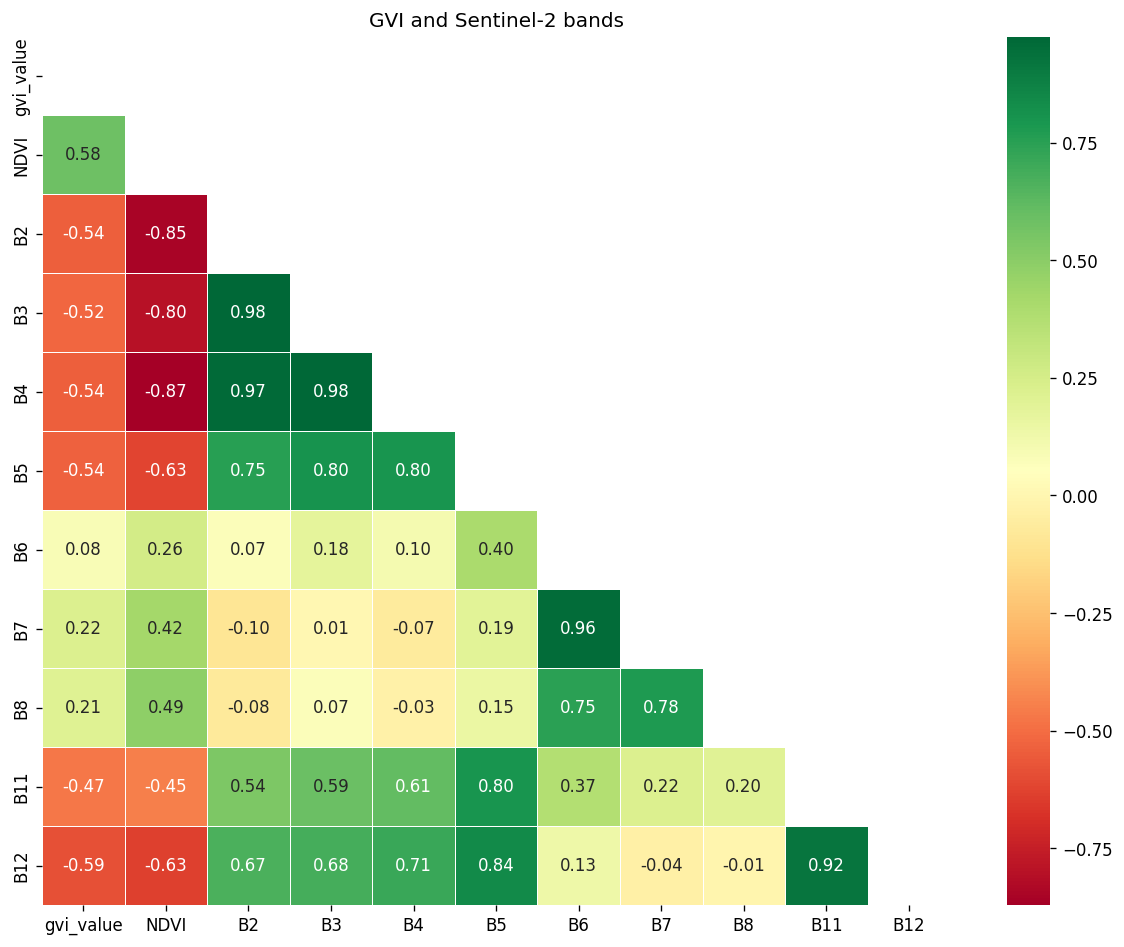

In [12]:
import seaborn as sns

correlation = training[["gvi_value", *SPECTRAL_FEATURES]].corr()
ranked = correlation["gvi_value"].drop("gvi_value").sort_values(ascending=False)
print("Correlation with GVI")
print(ranked.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation,
    mask=np.triu(np.ones_like(correlation, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.4,
    ax=ax,
)
ax.set_title("GVI and Sentinel-2 bands")
fig.tight_layout()
fig.savefig(DATA_DIR / "correlation_gvi.png", dpi=200)
plt.show()


## 10. Choose predictors

Importance is a random forest fit on an 80% split. Ablation then adds those bands one at a time and records 5-fold R² on that same training split. The model below uses the first five bands in that ranking, which is the set used for the paper. Read the curve before treating five as a cutoff: R² can keep rising after that.


feature  importance
    B12       0.272
     B2       0.150
   NDVI       0.127
     B5       0.085
     B7       0.079
     B8       0.066
    B11       0.062
     B6       0.058
     B4       0.052
     B3       0.050
Features used below: ['B12', 'B2', 'NDVI', 'B5', 'B7']
 1  B12     R2 0.3725
 2  B2      R2 0.3734
 3  NDVI    R2 0.4202
 4  B5      R2 0.4766
 5  B7      R2 0.5312
 6  B8      R2 0.5254
 7  B11     R2 0.5381
 8  B6      R2 0.5448
 9  B4      R2 0.5372
10  B3      R2 0.5364


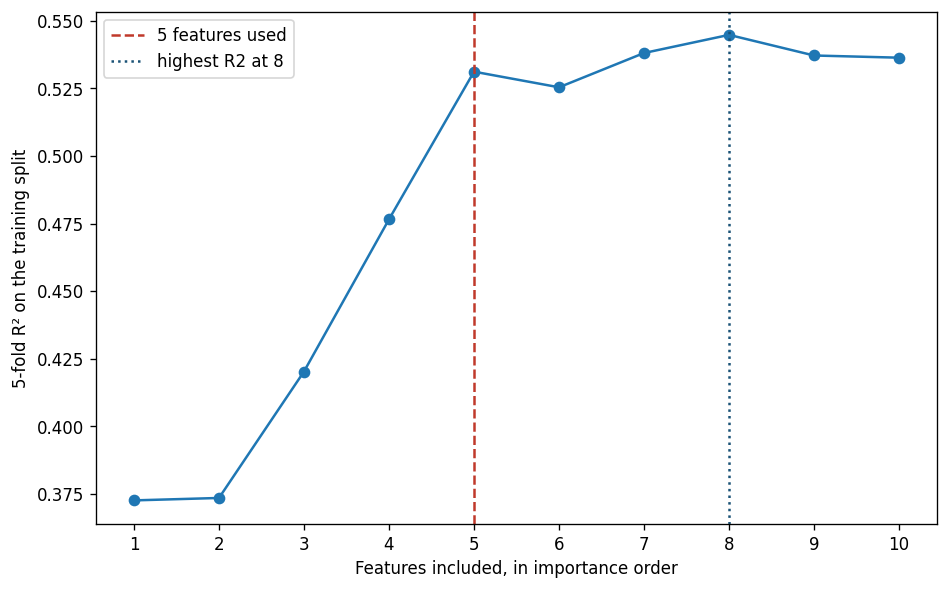

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split

N_FEATURES = 5

X_spectral = training[SPECTRAL_FEATURES]
y = training["gvi_value"]
X_fit, X_holdout, y_fit, y_holdout = train_test_split(
    X_spectral, y, test_size=0.2, random_state=42
)

ranker = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
ranker.fit(X_fit, y_fit)
importance = (
    pd.DataFrame({"feature": SPECTRAL_FEATURES, "importance": ranker.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print(importance.round(3).to_string(index=False))
selected_features = importance["feature"].head(N_FEATURES).tolist()
print("Features used below:", selected_features)

ablation_r2 = []
ordered = importance["feature"].tolist()
for count in range(1, len(ordered) + 1):
    subset = ordered[:count]
    scores = cross_val_score(
        RandomForestRegressor(n_estimators=100, random_state=42),
        X_fit[subset],
        y_fit,
        cv=5,
        scoring="r2",
    )
    ablation_r2.append(scores.mean())
    print(f"{count:2d}  {subset[-1]:<6}  R2 {scores.mean():.4f}")

best_count = int(np.argmax(ablation_r2)) + 1
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(ordered) + 1), ablation_r2, marker="o")
ax.axvline(N_FEATURES, color="#c0392b", linestyle="--", label=f"{N_FEATURES} features used")
if best_count != N_FEATURES:
    ax.axvline(best_count, color="#1a5276", linestyle=":", label=f"highest R2 at {best_count}")
ax.set_xlabel("Features included, in importance order")
ax.set_ylabel("5-fold R² on the training split")
ax.set_xticks(range(1, len(ordered) + 1))
ax.legend()
fig.tight_layout()
fig.savefig(DATA_DIR / "ablation_curve.png", dpi=200)
plt.show()


## 11. Fit and compare models

Global models see only the five bands. Linear models are fit on standardized bands. The spatial model adds UTM easting and northing, plus the same axes rotated 45°. The rotation is not new location information; it gives the trees another pair of axis-aligned splits. Coordinates are in metres (EPSG:32647). A random 80/20 split lets neighbouring points fall in both sets, so that test R² is optimistic once coordinates are included.

The spatial LightGBM also uses more trees than the global LightGBM row. Both numbers are printed. A 250 m block cross-validation is printed next to the random split so the coordinate effect can be judged without adjacent cells leaking across the split.

`RUN_GWR` refits geographically weighted regression in metres. Leave it off unless you want that baseline; bandwidth search is slow. The campus map uses the spatial model trained on the 80% split, saved to `data/spatial_lightgbm.joblib`.


In [14]:
import joblib
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

RUN_GWR = False
BLOCK_SIZE_M = 250


def add_planar_coords(frame, lat_col="lat", lon_col="lon"):
    located = gpd.GeoDataFrame(
        frame.copy(),
        geometry=gpd.points_from_xy(frame[lon_col], frame[lat_col]),
        crs="EPSG:4326",
    ).to_crs(epsg=UTM_EPSG)
    theta = np.radians(45)
    easting = located.geometry.x.to_numpy()
    northing = located.geometry.y.to_numpy()
    out = frame.copy()
    out["utm_x"] = easting
    out["utm_y"] = northing
    out["rot_45_x"] = easting * np.cos(theta) - northing * np.sin(theta)
    out["rot_45_y"] = easting * np.sin(theta) + northing * np.cos(theta)
    return out


def regression_scores(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }


spatial_columns = ["utm_x", "utm_y", "rot_45_x", "rot_45_y"]
model_frame = add_planar_coords(training)
model_features = selected_features + spatial_columns
X_all = model_frame[model_features]
y_all = model_frame["gvi_value"]
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[selected_features])
X_test_scaled = scaler.transform(X_test[selected_features])

rows = []
linear_models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
}
for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train)
    scores = regression_scores(y_test, model.predict(X_test_scaled))
    rows.append({"model": name, **scores})

tree_models = {
    "Random forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=42, verbose=-1),
    "XGBoost": xgb.XGBRegressor(random_state=42, n_jobs=-1),
}
for name, model in tree_models.items():
    model.fit(X_train[selected_features], y_train)
    scores = regression_scores(y_test, model.predict(X_test[selected_features]))
    rows.append({"model": name, **scores})

spatial_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)
spatial_model.fit(X_train, y_train)
spatial_scores = regression_scores(y_test, spatial_model.predict(X_test))
rows.append({"model": "Spatial LightGBM", **spatial_scores})

if RUN_GWR:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW

    coords_train = X_train[spatial_columns[:2]].to_numpy()
    coords_test = X_test[spatial_columns[:2]].to_numpy()
    y_train_column = y_train.to_numpy().reshape(-1, 1)
    bandwidth = Sel_BW(coords_train, y_train_column, X_train_scaled).search()
    gwr = GWR(coords_train, y_train_column, X_train_scaled, bandwidth).fit()
    gwr_pred = gwr.predict(coords_test, X_test_scaled).predy.flatten()
    rows.append({"model": f"GWR (bandwidth {bandwidth:.0f} m)", **regression_scores(y_test, gwr_pred)})

comparison = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
print(comparison.round(4).to_string(index=False))

block_id = (
    (model_frame["utm_x"] // BLOCK_SIZE_M).astype(int).astype(str)
    + "_"
    + (model_frame["utm_y"] // BLOCK_SIZE_M).astype(int).astype(str)
)
block_scores = cross_val_score(
    lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=10,
        num_leaves=31,
        random_state=42,
        verbose=-1,
    ),
    X_all,
    y_all,
    cv=GroupKFold(n_splits=5),
    groups=block_id,
    scoring="r2",
)
print(
    f"Spatial LightGBM, 5-fold blocks of {BLOCK_SIZE_M} m: "
    f"R2 {block_scores.mean():.4f} ± {block_scores.std():.4f}"
)

joblib.dump(
    {"model": spatial_model, "features": model_features, "spectral": selected_features},
    DATA_DIR / "spatial_lightgbm.joblib",
)
print(f"Random-split test R2 {spatial_scores['R2']:.4f}, RMSE {spatial_scores['RMSE']:.2f}")


           model     R2   RMSE
Spatial LightGBM 0.7558 4.9678
        LightGBM 0.5575 6.6883
   Random forest 0.5561 6.6987
         XGBoost 0.5161 6.9941
           Lasso 0.4431 7.5028
           Ridge 0.4430 7.5032
             OLS 0.4430 7.5035
Spatial LightGBM, 5-fold blocks of 250 m: R2 0.3220 ± 0.1581
Random-split test R2 0.7558, RMSE 4.97


## 12. Predict the campus grid

Each 10 m square needs the five selected bands and NDVI from a cloud-filtered Sentinel-2 median. If `data/campus_sentinel.csv` is already present it is reused. Otherwise the cell samples Earth Engine at the square centres. Rows with a missing pixel are dropped rather than filled with zero. The saved model is the one fit on the training split in section 11.


In [15]:
import joblib

PREDICTION_YEAR = 2025
SENTINEL_PATH = DATA_DIR / "campus_sentinel.csv"
bundle = joblib.load(DATA_DIR / "spatial_lightgbm.joblib")
spectral = bundle["spectral"]


def init_earth_engine():
    import ee

    project = os.environ.get("EARTHENGINE_PROJECT", "").strip()
    if not project:
        raise RuntimeError("Set EARTHENGINE_PROJECT, then run earthengine authenticate once.")
    ee.Initialize(project=project)
    return ee


def sentinel_median(ee, year, bands):
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )

    def add_ndvi(image):
        ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
        return image.addBands(ndvi)

    return collection.map(add_ndvi).median().select(bands)


def sample_bands(ee, image, points, id_col, lat_col, lon_col, batch_size=1000):
    extracted = []
    for start in range(0, len(points), batch_size):
        batch = points.iloc[start : start + batch_size]
        features = [
            ee.Feature(
                ee.Geometry.Point([float(row[lon_col]), float(row[lat_col])]),
                {id_col: str(row[id_col])},
            )
            for row in batch.to_dict(orient="records")
        ]
        sampled = image.sampleRegions(collection=ee.FeatureCollection(features), scale=10).getInfo()
        rows = [feature["properties"] for feature in sampled.get("features", [])]
        print(f"batch {start}: {len(rows)} pixels")
        if rows:
            extracted.append(pd.DataFrame(rows))
    if not extracted:
        raise RuntimeError("Earth Engine returned no samples.")
    table = pd.concat(extracted, ignore_index=True)
    table[id_col] = table[id_col].map(lambda value: str(value).removesuffix(".0"))
    return table


if SENTINEL_PATH.exists():
    campus_bands = pd.read_csv(SENTINEL_PATH)
    print(f"Loaded {len(campus_bands)} rows from {SENTINEL_PATH.name}")
else:
    ee = init_earth_engine()
    image = sentinel_median(ee, PREDICTION_YEAR, spectral)
    sampled = sample_bands(ee, image, master_grid, "grid_id", "lat", "lon")
    campus_bands = master_grid.copy()
    campus_bands["grid_id"] = campus_bands["grid_id"].map(lambda value: str(value).removesuffix(".0"))
    campus_bands = campus_bands.merge(sampled, on="grid_id", how="left")
    campus_bands.to_csv(SENTINEL_PATH, index=False)

campus_bands = campus_bands.dropna(subset=spectral).copy()
campus = add_planar_coords(campus_bands)
campus["predicted_gvi"] = bundle["model"].predict(campus[bundle["features"]])
prediction_path = DATA_DIR / "campus_gvi_prediction.csv"
campus[["grid_id", "lat", "lon", "predicted_gvi", *spectral]].to_csv(prediction_path, index=False)
print(f"{len(campus)} squares written to {prediction_path}")
print(campus["predicted_gvi"].describe().round(2).to_string())


Loaded 20455 rows from campus_sentinel.csv
20455 squares written to data/campus_gvi_prediction.csv
count    20455.00
mean        41.10
std          9.17
min         10.12
25%         35.30
50%         43.03
75%         47.33
max         77.48


## 13. Map the prediction

Squares come from the 10 m grid, coloured from pale yellow to dark green. The HTML file is large because every square is drawn. It is saved under `data/` and not embedded back into this notebook. Area A and Area B are the two insets marked on the paper figure.


In [16]:
import branca.colormap as cm

INSETS = {
    "Area A": [[18.8040, 98.9485], [18.8065, 98.9515]],
    "Area B": [[18.7940, 98.9530], [18.7970, 98.9570]],
}

squares = gpd.read_file(DATA_DIR / "master_grid_10m.geojson")
squares["grid_id"] = squares["grid_id"].astype(str)
mapped = squares.merge(
    campus[["grid_id", "predicted_gvi"]],
    on="grid_id",
    how="inner",
)
low = float(mapped["predicted_gvi"].min())
high = float(mapped["predicted_gvi"].max())
palette = cm.LinearColormap(["#f7fcb9", "#74c476", "#004529"], vmin=low, vmax=high)
palette.caption = "Predicted Green View Index (%)"

prediction_map = folium.Map(
    location=[campus["lat"].mean(), campus["lon"].mean()],
    zoom_start=15,
    tiles=MAPBOX_TILES,
    attr=MAPBOX_ATTR,
)
gvi_layer = folium.FeatureGroup(name="Predicted GVI", show=True)
folium.GeoJson(
    mapped,
    style_function=lambda feature: {
        "color": palette(feature["properties"]["predicted_gvi"]),
        "weight": 0.2,
        "fillColor": palette(feature["properties"]["predicted_gvi"]),
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(fields=["predicted_gvi"], aliases=["Predicted GVI %"]),
).add_to(gvi_layer)
gvi_layer.add_to(prediction_map)
palette.add_to(prediction_map)

inset_layer = folium.FeatureGroup(name="Area A and B", show=True)
for name, bounds in INSETS.items():
    folium.Rectangle(bounds=bounds, color="#111111", weight=2, fill=False, dash_array="4 4").add_to(
        inset_layer
    )
    folium.Marker(
        location=[bounds[1][0], bounds[0][1]],
        icon=folium.DivIcon(
            icon_size=(80, 20),
            icon_anchor=(0, 0),
            html=f'<div style="font-size:14px;font-weight:700;color:#111">{name}</div>',
        ),
    ).add_to(inset_layer)
inset_layer.add_to(prediction_map)
folium.LayerControl(collapsed=False).add_to(prediction_map)

prediction_map_path = DATA_DIR / "predicted_gvi_map.html"
prediction_map.save(prediction_map_path)
print(f"Map saved to {prediction_map_path}")


Map saved to data/predicted_gvi_map.html


## 14. Check against phone photos

`data/ground_truth_gvi.csv` holds the 50 smartphone locations. Each location is paired with the predicted GVI of the nearest 10 m square (median distance about 4 m). The scatter plot is the agreement between what a person photographed and what the Sentinel-2 model estimated.

The text box reports the statistics of these 50 pairs. An earlier Colab run sampled Sentinel-2 at the exact phone coordinate and reported $R^2$ = 0.289, RMSE = 13.77%, and $r$ = 0.556. That predicted vector was not saved, so this figure uses the nearest square instead.

Side-by-side SegFormer masks of the phone photos need the original images. This table stores only the location average, not the photos.


In [17]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

gt = pd.read_csv(DATA_DIR / "ground_truth_gvi.csv")
campus_pred = pd.read_csv(DATA_DIR / "campus_gvi_prediction.csv")
lat = campus_pred["lat"].to_numpy()
lon = campus_pred["lon"].to_numpy()
pairs = []
for record in gt.itertuples(index=False):
    distance = np.hypot(lat - record.Center_Lat, lon - record.Center_Lon)
    nearest = int(np.argmin(distance))
    pairs.append({
        "Group_ID": record.Group_ID,
        "ground_truth_gvi": record.Average_GVI_Percent,
        "predicted_gvi": campus_pred.iloc[nearest]["predicted_gvi"],
        "grid_id": campus_pred.iloc[nearest]["grid_id"],
        "distance_m": float(distance[nearest] * 111_320),
    })
paired = pd.DataFrame(pairs)
observed = paired["ground_truth_gvi"].to_numpy()
predicted = paired["predicted_gvi"].to_numpy()
r2 = r2_score(observed, predicted)
rmse = float(np.sqrt(mean_squared_error(observed, predicted)))
r_value, p_value = pearsonr(observed, predicted)
print(f"n    {len(paired)}")
print(f"R2   {r2:.4f}")
print(f"RMSE {rmse:.2f}")
print(f"r    {r_value:.4f}   p {p_value:.4e}")
print(f"nearest square, metres: median {paired['distance_m'].median():.1f}, max {paired['distance_m'].max():.1f}")
paired.to_csv(DATA_DIR / "ground_truth_vs_predicted.csv", index=False)

trend = LinearRegression().fit(observed.reshape(-1, 1), predicted)
x_line = np.linspace(5, 90, 200)
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.scatter(observed, predicted, s=52, c="#1e8449", edgecolor="#1c2833", linewidth=0.45, zorder=3, label="Phone locations (n = 50)")
ax.plot(x_line, trend.predict(x_line.reshape(-1, 1)), color="#1a5276", lw=2, label="Line of best fit")
ax.plot([5, 90], [5, 90], linestyle="--", color="#922b21", lw=1.2, label="1:1 line")
ax.set_xlim(5, 90)
ax.set_ylim(5, 90)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Ground-truth GVI (%) — smartphone")
ax.set_ylabel("Predicted GVI (%) — Sentinel-2 model")
ax.set_title("Smartphone view versus predicted green view")
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f}%\n$r$ = {r_value:.4f}\n$p$ < 0.001",
    transform=ax.transAxes, va="top", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#b0b0b0", alpha=0.95),
)
ax.legend(loc="lower right")
ax.grid(True, linestyle=":", alpha=0.55)
fig.tight_layout()
fig.savefig(DATA_DIR / "ground_truth_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


Skipped. data/ground_truth_gvi.csv is not in the project.
